# 📦 Notebook 1: Data Inspection, Visualization & Cleaning
### SupplyChain-AI-Agent | AIML Lab Assignment

**Goal:** Understand the raw DataCo Supply Chain dataset, visualize key patterns, handle missing values, and produce a clean CSV for the next pipeline stage.

**Input:** `Datasets/DataCoSupplyChainDataset.csv`  
**Output:** `Datasets/cleaned_data.csv`

---

## 0. Imports & Setup

In [53]:
# ── Import core data science libraries ────────────────────────────────────────
import pandas as pd          # pandas: used for loading, manipulating, and saving tabular data (DataFrames)
import numpy as np           # numpy: used for fast numerical operations on arrays
import matplotlib.pyplot as plt  # matplotlib: used for creating all charts and plots
import seaborn as sns        # seaborn: built on top of matplotlib, gives nicer statistical charts
import warnings              # warnings: built-in Python module to control warning messages

# Suppress non-critical warning messages so the output stays clean
warnings.filterwarnings('ignore')

# Set a clean white background with muted colors for all seaborn plots
# font_scale=1.1 makes all text in plots slightly larger and easier to read
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# Set the default size of every matplotlib figure to 12 inches wide × 5 inches tall
plt.rcParams['figure.figsize'] = (12, 5)

# Set plot resolution to 100 dots-per-inch so plots are sharp in the notebook
plt.rcParams['figure.dpi'] = 100

# Confirm that all libraries loaded without errors
print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


---
## 1. Load the Dataset

In [54]:
# Define the file path to the raw DataCo dataset
# The file uses latin-1 encoding because it contains special characters (e.g. accented letters in place names)
DATA_PATH = '../Datasets/DataCoSupplyChainDataset.csv'

# Read the CSV file into a pandas DataFrame
# encoding='latin-1' tells pandas how to decode bytes — UTF-8 would raise a UnicodeDecodeError on this file
df = pd.read_csv(DATA_PATH, encoding='latin-1')

# Print how many rows and columns were loaded
# df.shape returns (rows, columns) as a tuple
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

# Display the first 3 rows so we can visually inspect the raw data
df.head(3)

Dataset loaded: 180,519 rows × 53 columns


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


---
## 2. Data Inspection
### 2.1 Shape, Types & Basic Info

In [55]:
# Print a high-level overview of the dataset's size and memory usage
print('=' * 55)
print('  DATASET OVERVIEW')
print('=' * 55)

# df.shape[0] = number of rows (one row = one order/shipment record)
print(f'  Rows         : {df.shape[0]:,}')

# df.shape[1] = number of columns (one column = one attribute/feature)
print(f'  Columns      : {df.shape[1]}')

# memory_usage(deep=True) counts actual bytes including object columns
# dividing by 1e6 converts bytes → megabytes
print(f'  Memory usage : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print('=' * 55)

# Count how many columns belong to each data type (str, float64, int64)
dtype_counts = df.dtypes.value_counts()
print('\nColumn dtypes breakdown:')
# Loop through each data type and show how many columns have that type
for dtype, count in dtype_counts.items():
    print(f'  {str(dtype):<12} → {count} columns')

  DATASET OVERVIEW
  Rows         : 180,519
  Columns      : 53
  Memory usage : 313.44 MB

Column dtypes breakdown:
  str          → 24 columns
  float64      → 15 columns
  int64        → 14 columns


In [56]:
# Build a detailed column-by-column summary table
# For each column we want: data type, non-null count, null count, and number of unique values
info_df = pd.DataFrame({
    'Dtype':          df.dtypes.astype(str),              # data type of each column
    'Non-Null Count': df.notnull().sum(),                 # how many rows have a value
    'Null Count':     df.isnull().sum(),                  # how many rows are missing
    'Unique Values':  df.nunique()                        # how many distinct values exist
}).rename_axis('Column')

print('All columns and their data types:\n')
info_df   # display the summary table

All columns and their data types:



,Dtype,Non-Null Count,Null Count,Unique Values
Column,,,,
Type,str,180519,0,4
Days for shipping (real),int64,180519,0,7
Days for shipment (scheduled),int64,180519,0,4
Benefit per order,float64,180519,0,21998
Sales per customer,float64,180519,0,2927
Delivery Status,str,180519,0,4
Late_delivery_risk,int64,180519,0,2
Category Id,int64,180519,0,51
Category Name,str,180519,0,50


### 2.2 Statistical Summary

In [57]:
# df.describe() computes count, mean, std, min, 25th/50th/75th percentile, max
# for every numeric column — great for spotting outliers and unusual ranges
# .T transposes the result so each row is a column (easier to read with many columns)
# .round(2) limits decimals to 2 for cleaner output
print('── Numeric Columns Summary ──')
df.describe().T.round(2)

── Numeric Columns Summary ──


,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.50,1.62,0.00,2.00,3.00,5.00,6.00
Days for shipment (scheduled),180519.0,2.93,1.37,0.00,2.00,4.00,4.00,4.00
Benefit per order,180519.0,21.97,104.43,-4274.98,7.00,31.52,64.80,911.80
Sales per customer,180519.0,183.11,120.04,7.49,104.38,163.99,247.40,1939.99
Late_delivery_risk,180519.0,0.55,0.50,0.00,0.00,1.00,1.00,1.00
Category Id,180519.0,31.85,15.64,2.00,18.00,29.00,45.00,76.00
Customer Id,180519.0,6691.38,4162.92,1.00,3258.50,6457.00,9779.00,20757.00
Customer Zipcode,180516.0,35921.13,37542.46,603.00,725.00,19380.00,78207.00,99205.00
Department Id,180519.0,5.44,1.63,2.00,4.00,5.00,7.00,12.00
Latitude,180519.0,29.72,9.81,-33.94,18.27,33.14,39.28,48.78


In [58]:
# select_dtypes(include='object') selects only text/string columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'── Categorical Columns ({len(cat_cols)} total) ──\n')

# Loop through each categorical column and show:
#   - how many unique values it contains
#   - the top 3 most frequent values and their counts
for col in cat_cols:
    top_vals = df[col].value_counts().head(3).to_dict()   # dict of top 3 value → count
    print(f'  {col:<45} | unique={df[col].nunique():<6} | top3={top_vals}')

── Categorical Columns (24 total) ──

  Type                                          | unique=4      | top3={'DEBIT': 69295, 'TRANSFER': 49883, 'PAYMENT': 41725}
  Delivery Status                               | unique=4      | top3={'Late delivery': 98977, 'Advance shipping': 41592, 'Shipping on time': 32196}
  Category Name                                 | unique=50     | top3={'Cleats': 24551, "Men's Footwear": 22246, "Women's Apparel": 21035}
  Customer City                                 | unique=563    | top3={'Caguas': 66770, 'Chicago': 3885, 'Los Angeles': 3417}
  Customer Country                              | unique=2      | top3={'EE. UU.': 111146, 'Puerto Rico': 69373}
  Customer Email                                | unique=1      | top3={'XXXXXXXXX': 180519}
  Customer Fname                                | unique=782    | top3={'Mary': 65150, 'James': 1835, 'Robert': 1759}
  Customer Lname                                | unique=1109   | top3={'Smith': 64104, 'Johnson

### 2.3 Missing Values Analysis

In [59]:
# Count missing values (NaN) in each column
missing = df.isnull().sum()

# Calculate what percentage of that column is missing
# dividing by total rows and multiplying by 100 gives the percentage
missing_pct = (missing / len(df) * 100).round(2)

# Combine counts and percentages into one DataFrame for easy reading
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)
# .query('`Missing Count` > 0') keeps only columns that actually have missing values
# .sort_values(...) puts the worst offenders at the top

if missing_df.empty:
    print('✅ No missing values found!')
else:
    print(f'Columns with missing values: {len(missing_df)}\n')
    print(missing_df.to_string())   # print without truncation

Columns with missing values: 4

                     Missing Count  Missing %
Product Description         180519     100.00
Order Zipcode               155679      86.24
Customer Zipcode                 3       0.00
Customer Lname                   8       0.00


### 2.4 Duplicate Rows

In [60]:
# Check if any rows are exact duplicates of another row
# .duplicated() returns a boolean Series — True where the row is a duplicate
# .sum() counts how many True values there are
dup_count = df.duplicated().sum()
print(f'Duplicate rows found: {dup_count:,}')

# Also check target column distribution — tells us if classes are balanced
# Late_delivery_risk = 1 means the order was late, 0 means on time
print('\nTarget variable (Late_delivery_risk) distribution:')
print(df['Late_delivery_risk'].value_counts())
print(f'Late delivery rate: {df["Late_delivery_risk"].mean()*100:.1f}%')

Duplicate rows found: 0

Target variable (Late_delivery_risk) distribution:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64
Late delivery rate: 54.8%


---
## 3. Exploratory Visualizations
### 3.1 Target Variable — Late Delivery Distribution

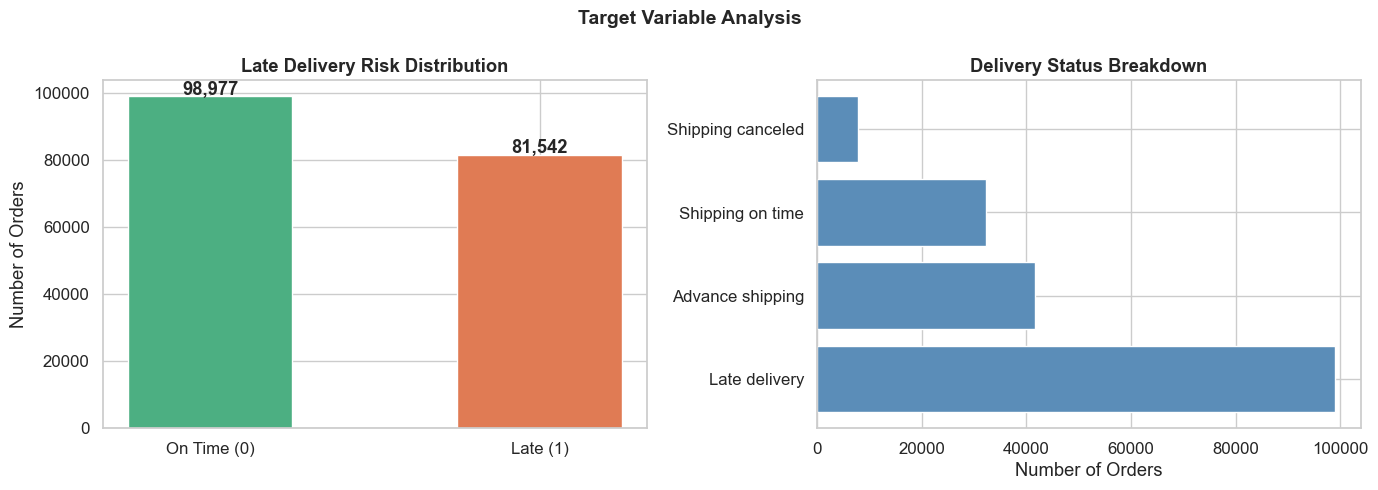

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left chart: count of on-time vs late orders ───────────────────────────
# value_counts() counts how many 0s and 1s are in the target column
target_counts = df['Late_delivery_risk'].value_counts()

# Plot as a bar chart — green for on-time (0), red for late (1)
bars = axes[0].bar(['On Time (0)', 'Late (1)'], target_counts.values,
                   color=['#4CAF82', '#E07B54'], edgecolor='white', width=0.5)
axes[0].set_title('Late Delivery Risk Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Orders')

# Add count labels on top of each bar so exact numbers are visible
for bar, val in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', fontweight='bold')

# ── Right chart: Delivery Status breakdown ───────────────────────────────
# Shows 4 categories: Late delivery, Advance shipping, Shipping on time, Cancelled
status_counts = df['Delivery Status'].value_counts()
axes[1].barh(status_counts.index, status_counts.values, color='#5B8DB8')
axes[1].set_title('Delivery Status Breakdown', fontweight='bold')
axes[1].set_xlabel('Number of Orders')

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Shipping Mode vs Late Delivery

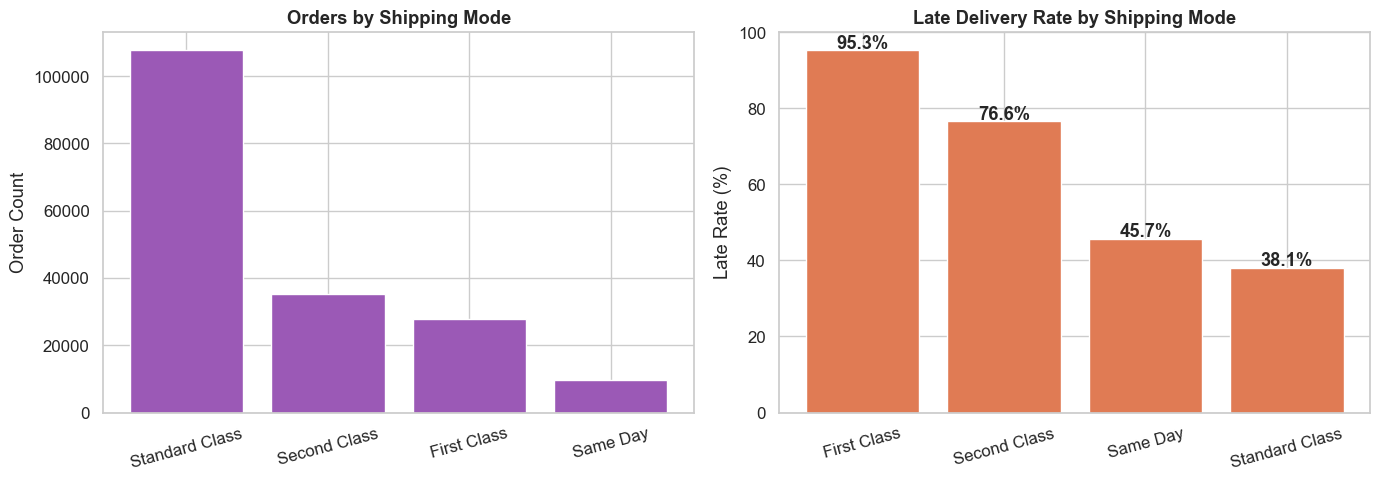

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: how many orders each shipping mode handled ─────────────────────
mode_counts = df['Shipping Mode'].value_counts()
axes[0].bar(mode_counts.index, mode_counts.values, color='#9B59B6', edgecolor='white')
axes[0].set_title('Orders by Shipping Mode', fontweight='bold')
axes[0].set_ylabel('Order Count')
axes[0].tick_params(axis='x', rotation=15)  # rotate labels to avoid overlap

# ── Right: late delivery RATE per shipping mode ───────────────────────────
# groupby splits data by Shipping Mode, then .mean() on a binary column gives the rate
mode_late_rate = df.groupby('Shipping Mode')['Late_delivery_risk'].mean() * 100
mode_late_rate = mode_late_rate.sort_values(ascending=False)
axes[1].bar(mode_late_rate.index, mode_late_rate.values,
            color='#E07B54', edgecolor='white')
axes[1].set_title('Late Delivery Rate by Shipping Mode', fontweight='bold')
axes[1].set_ylabel('Late Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

# Annotate each bar with its exact percentage
for i, v in enumerate(mode_late_rate.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 3.3 Order Region & Market Distribution

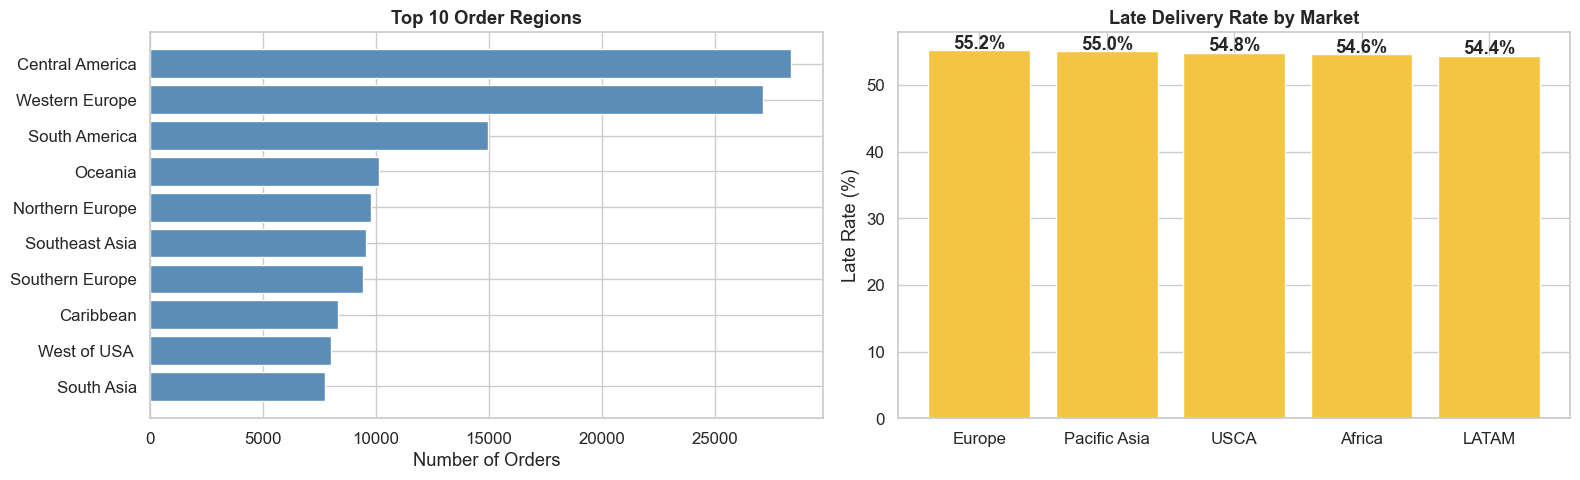

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Top 10 order regions by volume ──────────────────────────────────────
region_counts = df['Order Region'].value_counts().head(10)
axes[0].barh(region_counts.index[::-1], region_counts.values[::-1],
             color='#5B8DB8')   # [::-1] reverses to show highest on top
axes[0].set_title('Top 10 Order Regions', fontweight='bold')
axes[0].set_xlabel('Number of Orders')

# ── Late delivery rate by Market ─────────────────────────────────────────
# Each market (LATAM, Europe, etc.) may have different delay patterns
market_late = df.groupby('Market')['Late_delivery_risk'].mean() * 100
market_late = market_late.sort_values(ascending=False)
axes[1].bar(market_late.index, market_late.values, color='#F4C542', edgecolor='white')
axes[1].set_title('Late Delivery Rate by Market', fontweight='bold')
axes[1].set_ylabel('Late Rate (%)')
for i, v in enumerate(market_late.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 3.4 Delivery Time & Scheduled Days Analysis

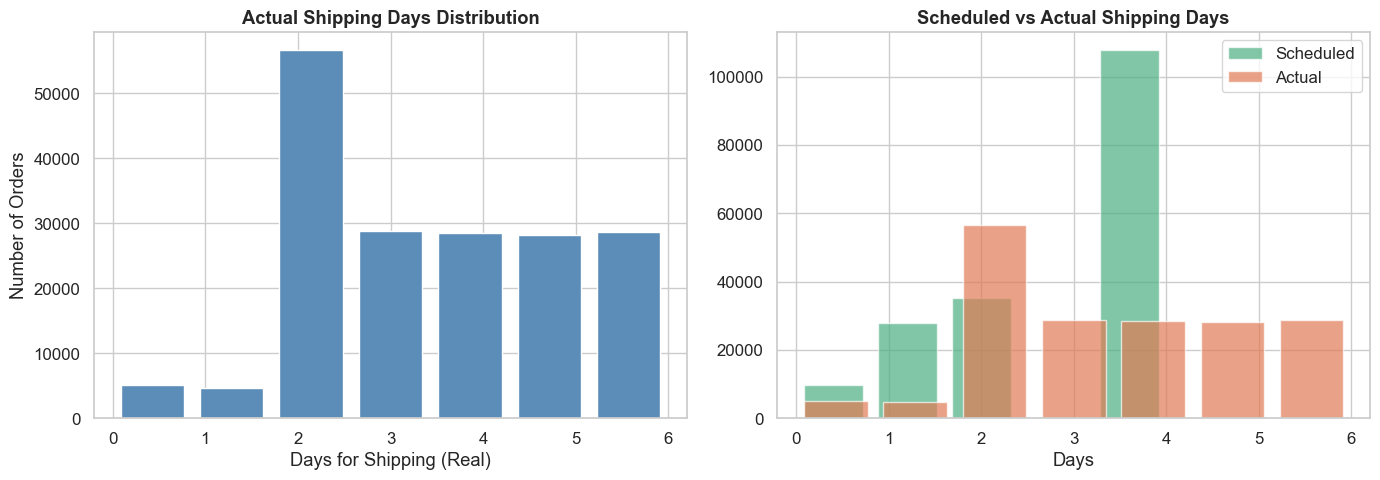

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Distribution of actual shipping days ─────────────────────────────────
# This shows us the spread of how long orders actually take to ship
axes[0].hist(df['Days for shipping (real)'], bins=7,
             color='#5B8DB8', edgecolor='white', rwidth=0.8)
axes[0].set_title('Actual Shipping Days Distribution', fontweight='bold')
axes[0].set_xlabel('Days for Shipping (Real)')
axes[0].set_ylabel('Number of Orders')

# ── Scheduled vs actual shipping days — side by side comparison ──────────
# Shows whether the company tends to be optimistic (schedule < actual)
axes[1].hist(df['Days for shipment (scheduled)'], bins=5,
             color='#4CAF82', edgecolor='white', alpha=0.7,
             rwidth=0.8, label='Scheduled')
axes[1].hist(df['Days for shipping (real)'], bins=7,
             color='#E07B54', edgecolor='white', alpha=0.7,
             rwidth=0.8, label='Actual')
axes[1].set_title('Scheduled vs Actual Shipping Days', fontweight='bold')
axes[1].set_xlabel('Days')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.5 Sales & Profit Distributions

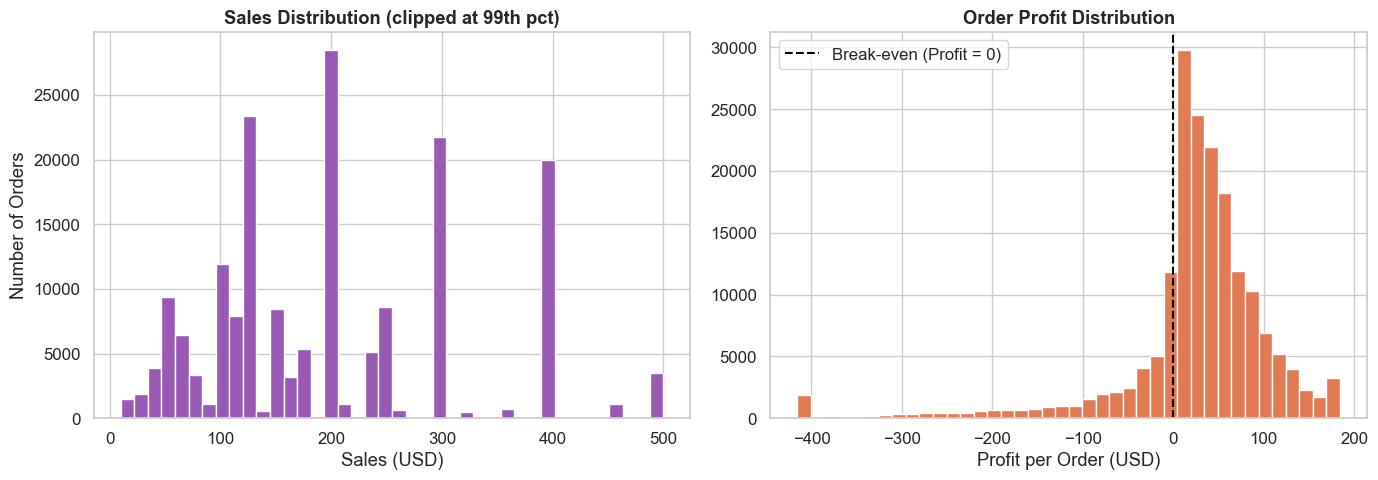

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Sales distribution ───────────────────────────────────────────────────
# Clipping at 99th percentile removes extreme outliers for a cleaner plot
sales_clip = df['Sales'].clip(upper=df['Sales'].quantile(0.99))
axes[0].hist(sales_clip, bins=40, color='#9B59B6', edgecolor='white')
axes[0].set_title('Sales Distribution (clipped at 99th pct)', fontweight='bold')
axes[0].set_xlabel('Sales (USD)')
axes[0].set_ylabel('Number of Orders')

# ── Profit per order distribution ────────────────────────────────────────
# Negative profit means the company lost money on that order
profit_clip = df['Order Profit Per Order'].clip(
    lower=df['Order Profit Per Order'].quantile(0.01),
    upper=df['Order Profit Per Order'].quantile(0.99)
)
axes[1].hist(profit_clip, bins=40, color='#E07B54', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5,
                label='Break-even (Profit = 0)')  # vertical line at zero profit
axes[1].set_title('Order Profit Distribution', fontweight='bold')
axes[1].set_xlabel('Profit per Order (USD)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.6 Top Product Categories

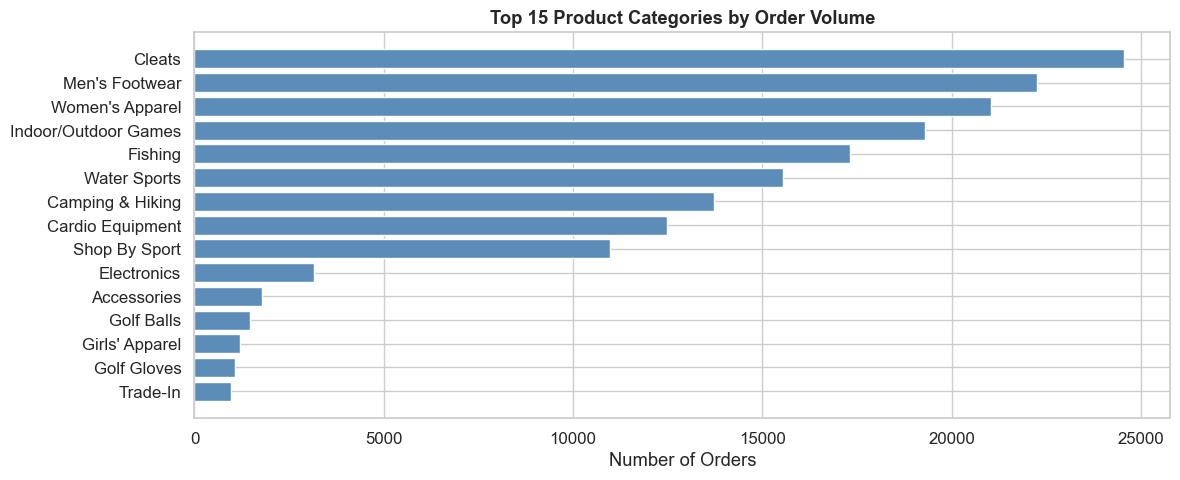

In [66]:
fig, ax = plt.subplots(figsize=(12, 5))

# Count orders per category and take top 15
top_cats = df['Category Name'].value_counts().head(15)

# Horizontal bar chart so long category names fit without overlap
ax.barh(top_cats.index[::-1], top_cats.values[::-1], color='#5B8DB8')
ax.set_title('Top 15 Product Categories by Order Volume', fontweight='bold')
ax.set_xlabel('Number of Orders')

plt.tight_layout()
plt.show()

### 3.7 Order Trends Over Time

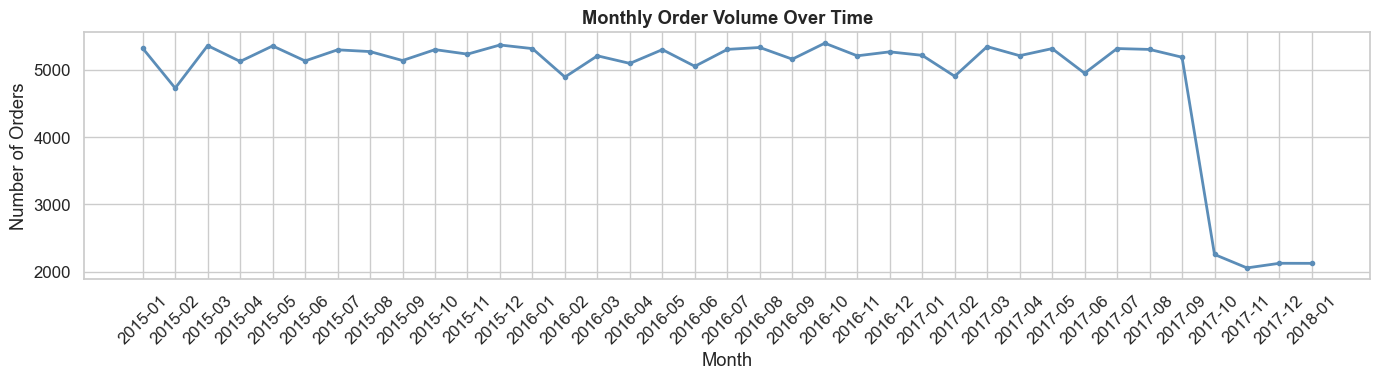

In [67]:
# Convert order date column to datetime so we can extract the year-month
order_col = 'order date (DateOrders)'
df_temp = df.copy()   # work on a copy to avoid modifying the original
df_temp[order_col] = pd.to_datetime(df_temp[order_col], errors='coerce')

# Extract year-month as a period string (e.g. '2017-01') for grouping
df_temp['year_month'] = df_temp[order_col].dt.to_period('M')

# Count total orders per month — shows seasonality and data coverage
monthly_orders = df_temp['year_month'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_orders.index.astype(str), monthly_orders.values,
        color='#5B8DB8', linewidth=2, marker='o', markersize=3)
ax.set_title('Monthly Order Volume Over Time', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
ax.tick_params(axis='x', rotation=45)  # rotate month labels to avoid overlap
plt.tight_layout()
plt.show()

### 3.8 Correlation Heatmap (Numeric Features)

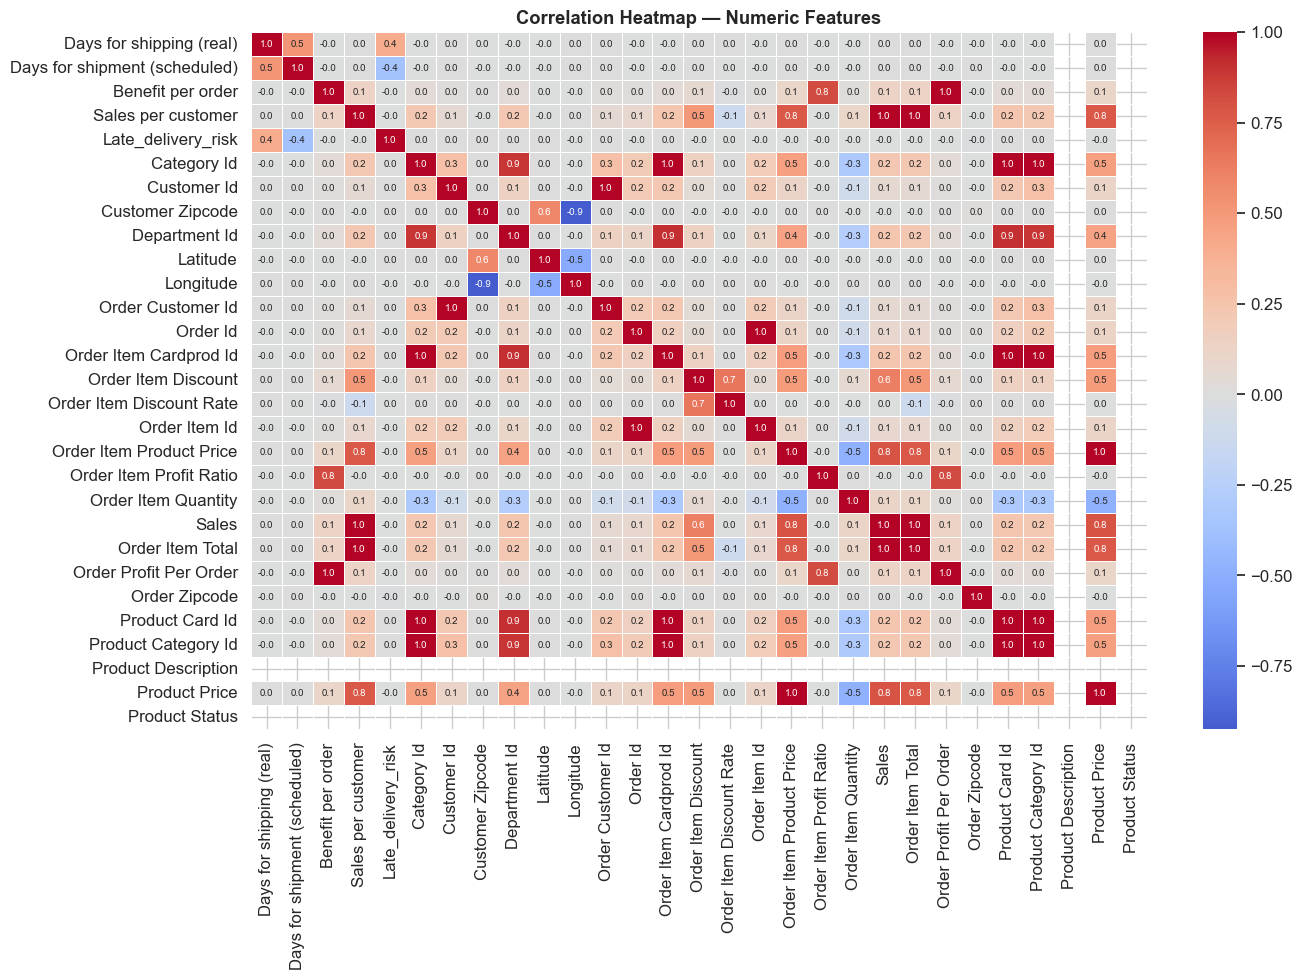

In [68]:
# Select only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include='number')

# .corr() computes Pearson correlation between every pair of numeric columns
# Values range from -1 (perfect negative) to +1 (perfect positive)
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(14, 10))

# sns.heatmap draws a color-coded grid where darker = stronger correlation
# annot=True prints the actual correlation value in each cell
# fmt='.1f' formats numbers to 1 decimal place
# cmap='coolwarm' uses blue for negative, red for positive correlations
# linewidths=0.5 draws thin white lines between cells for readability
sns.heatmap(corr_matrix, annot=True, fmt='.1f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Correlation Heatmap — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

### 3.9 Outlier Detection — Boxplots

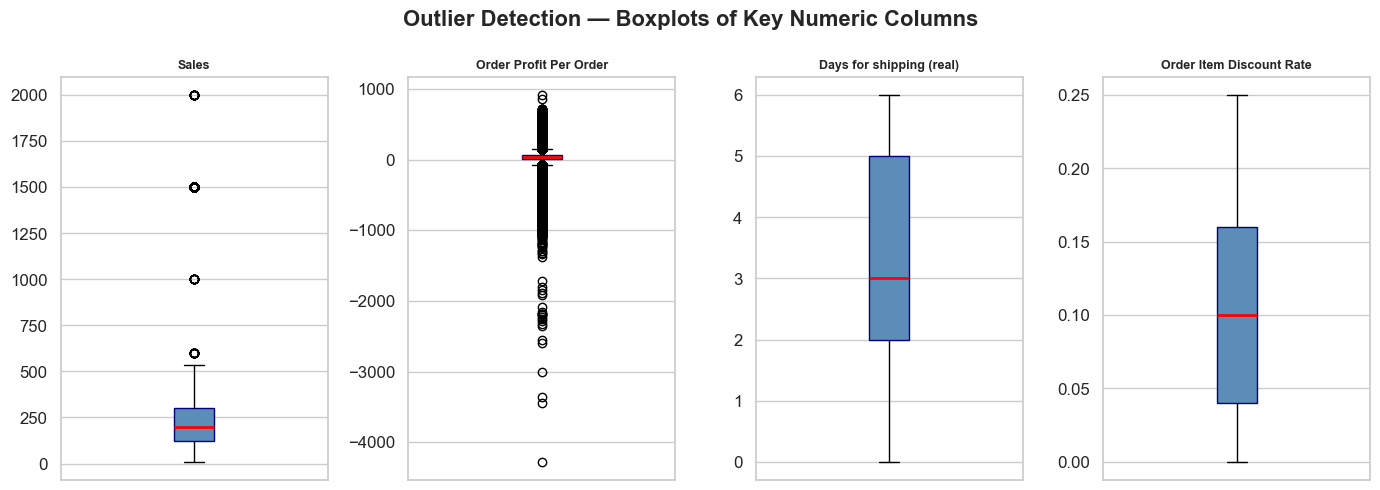

In [69]:
# Boxplots reveal outliers — dots beyond the whiskers are extreme values
# The box shows Q1→Q3 (middle 50% of data), the line inside is the median
key_numeric = ['Sales', 'Order Profit Per Order',
               'Days for shipping (real)', 'Order Item Discount Rate']
key_numeric = [c for c in key_numeric if c in df.columns]  # safety check

fig, axes = plt.subplots(1, len(key_numeric), figsize=(14, 5))

for ax, col in zip(axes, key_numeric):
    # Plot boxplot for each selected numeric column
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#5B8DB8', color='navy'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontweight='bold', fontsize=9)
    ax.set_xticks([])  # hide x-axis tick since there is only one box

plt.suptitle('Outlier Detection — Boxplots of Key Numeric Columns',
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Data Cleaning
### 4.1 Drop Irrelevant / Redundant Columns

In [70]:
# Columns to remove — each reason is explained:
drop_cols = [
    'Product Description',   # 100% missing — completely empty column, useless
    'Product Image',         # URL string — not a usable feature for ML
    'Order Zipcode',         # 86% missing and not predictive for delay
    'Customer Email',        # only 1 unique value ('XXXXXXXXX') — anonymised, no info
    'Customer Password',     # only 1 unique value ('XXXXXXXXX') — anonymised, no info
    'Customer Fname',        # personal name — not useful for predicting delays
    'Customer Lname',        # personal name — not useful for predicting delays
]

# Only drop columns that actually exist (avoids KeyError if already removed)
drop_cols = [c for c in drop_cols if c in df.columns]

# Make a clean copy of the DataFrame without the dropped columns
df_clean = df.drop(columns=drop_cols)

print(f'Dropped {len(drop_cols)} columns: {drop_cols}')
print(f'Remaining shape: {df_clean.shape}')

Dropped 7 columns: ['Product Description', 'Product Image', 'Order Zipcode', 'Customer Email', 'Customer Password', 'Customer Fname', 'Customer Lname']
Remaining shape: (180519, 46)


### 4.2 Handle Missing Values

In [71]:
# Strategy:
#   Numeric columns  → fill missing values with the MEDIAN (robust to outliers)
#   Categorical columns → fill missing values with the MODE (most common value)

# Get all numeric column names in the cleaned DataFrame
num_cols_clean = df_clean.select_dtypes(include='number').columns

# Get all text/categorical column names
cat_cols_clean = df_clean.select_dtypes(include='object').columns

# Fill numeric columns with their median where values are missing
for col in num_cols_clean:
    if df_clean[col].isnull().any():        # only process if there are actual NaNs
        median_val = df_clean[col].median() # compute median ignoring NaN values
        df_clean[col] = df_clean[col].fillna(median_val)   # replace NaN with median
        print(f'  [Numeric] {col!r} → filled with median={median_val:.2f}')

# Fill categorical columns with their most frequent value (mode)
for col in cat_cols_clean:
    if df_clean[col].isnull().any():        # only process if there are actual NaNs
        mode_val = df_clean[col].mode()[0]  # .mode() returns a Series; [0] = top value
        df_clean[col] = df_clean[col].fillna(mode_val)     # replace NaN with mode
        print(f"  [Categorical] {col!r} → filled with mode='{mode_val}'")

# Confirm no missing values remain anywhere in the DataFrame
print(f'\n✅ Missing values after cleaning: {df_clean.isnull().sum().sum()}')

  [Numeric] 'Customer Zipcode' → filled with median=19380.00

✅ Missing values after cleaning: 0


### 4.3 Remove Duplicate Rows

In [72]:
# Record how many rows exist before removing duplicates
before = len(df_clean)

# drop_duplicates() removes rows that are identical to a previous row
# This keeps the first occurrence of any duplicated row
df_clean = df_clean.drop_duplicates()

# Record how many rows remain after removing duplicates
after = len(df_clean)

print(f'Removed {before - after:,} duplicate rows.')
print(f'Remaining rows: {after:,}')

Removed 0 duplicate rows.
Remaining rows: 180,519


### 4.4 Fix Data Types

In [73]:
# The date columns were loaded as plain strings — convert them to datetime objects
# so we can later extract month, day-of-week, quarter etc. in Notebook 2
date_cols = ['order date (DateOrders)', 'shipping date (DateOrders)']

for col in date_cols:
    if col in df_clean.columns:
        # pd.to_datetime() converts strings like '1/18/2018 12:27' into proper datetime
        # errors='coerce' turns any unparseable value into NaT (Not a Time) instead of crashing
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
        print(f"  '{col}' → converted to datetime")

# The Late_delivery_risk column (0 or 1) may have been read as float due to NaNs earlier
# We explicitly cast it to integer so it stays as a binary flag
flag_cols = ['Late_delivery_risk']
for col in flag_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(int)   # float 1.0 → int 1
        print(f"  '{col}' → converted to int")

print('\n✅ Data types fixed.')

  'order date (DateOrders)' → converted to datetime
  'shipping date (DateOrders)' → converted to datetime
  'Late_delivery_risk' → converted to int

✅ Data types fixed.


### 4.5 Clip Extreme Outliers in Key Numeric Columns

In [74]:
# Instead of removing outlier rows (which loses data), we CLIP values:
# any value below the 1st percentile is set to the 1st percentile value
# any value above the 99th percentile is set to the 99th percentile value
# This keeps all rows but reduces extreme values that can skew ML models

# List of financial columns where extreme outliers are most harmful
clip_cols = ['Sales', 'Order Profit Per Order', 'Order Item Total', 'Benefit per order']

# Only process columns that exist in the cleaned DataFrame
clip_cols = [c for c in clip_cols if c in df_clean.columns]

for col in clip_cols:
    lo = df_clean[col].quantile(0.01)  # 1st percentile — lower bound
    hi = df_clean[col].quantile(0.99)  # 99th percentile — upper bound
    before_range = df_clean[col].max() - df_clean[col].min()  # range before clipping
    df_clean[col] = df_clean[col].clip(lo, hi)                # apply clip
    after_range = df_clean[col].max() - df_clean[col].min()   # range after clipping
    print(f"  '{col}': clipped to [{lo:.2f}, {hi:.2f}] | range {before_range:.2f} → {after_range:.2f}")

print('\n✅ Outliers clipped.')

  'Sales': clipped to [24.99, 499.95] | range 1990.00 → 474.96
  'Order Profit Per Order': clipped to [-415.60, 184.23] | range 5186.78 → 599.83
  'Order Item Total': clipped to [22.49, 464.95] | range 1932.50 → 442.46
  'Benefit per order': clipped to [-415.60, 184.23] | range 5186.78 → 599.83

✅ Outliers clipped.


### 4.6 Standardise String Columns

In [75]:
# Some text columns have inconsistent capitalisation e.g. 'late delivery', 'Late Delivery', 'LATE DELIVERY'
# We standardise to Title Case and strip leading/trailing whitespace
# This prevents the same category from appearing as multiple different values

# Key categorical columns where capitalisation inconsistency was observed
str_cols = ['Category Name', 'Department Name', 'Customer Segment',
            'Shipping Mode', 'Order Status', 'Market', 'Delivery Status']

# Only process columns that exist
str_cols = [c for c in str_cols if c in df_clean.columns]

for col in str_cols:
    # .astype(str) ensures no non-string values cause errors
    # .str.strip() removes leading and trailing spaces
    # .str.title() converts to Title Case: 'late delivery' → 'Late Delivery'
    df_clean[col] = df_clean[col].astype(str).str.strip().str.title()

print(f'Standardised {len(str_cols)} string columns: {str_cols}')

Standardised 7 string columns: ['Category Name', 'Department Name', 'Customer Segment', 'Shipping Mode', 'Order Status', 'Market', 'Delivery Status']


---
## 5. Post-Cleaning Summary

In [76]:
# Print a side-by-side comparison of the dataset before and after cleaning
print('=' * 55)
print('  CLEANING SUMMARY')
print('=' * 55)

# df.shape gives original dimensions; df_clean.shape gives cleaned dimensions
print(f'  Original shape  : {df.shape}')
print(f'  Cleaned shape   : {df_clean.shape}')

# How many rows were dropped (should be 0 since we only clipped outliers)
print(f'  Rows removed    : {df.shape[0] - df_clean.shape[0]:,}')

# How many columns were removed
print(f'  Cols removed    : {df.shape[1] - df_clean.shape[1]}')

# Confirm no nulls remain — .sum().sum() adds up all NaN counts across all columns
print(f'  Missing values  : {df_clean.isnull().sum().sum()}')

# Confirm no duplicates remain
print(f'  Duplicate rows  : {df_clean.duplicated().sum()}')
print('=' * 55)

# Preview first 3 rows of the cleaned dataset
df_clean.head(3)

  CLEANING SUMMARY
  Original shape  : (180519, 53)
  Cleaned shape   : (180519, 46)
  Rows removed    : 0
  Cols removed    : 7
  Missing values  : 0
  Duplicate rows  : 0


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance Shipping,0,73,Sporting Goods,Caguas,...,Southeast Asia,Java Occidental,Complete,1360,73,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late Delivery,1,73,Sporting Goods,Caguas,...,South Asia,Rajastán,Pending,1360,73,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping On Time,0,73,Sporting Goods,San Jose,...,South Asia,Rajastán,Closed,1360,73,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class


---
## 6. Save Cleaned Data

In [77]:
# Define where to save the cleaned CSV file
OUTPUT_PATH = '../Datasets/cleaned_data.csv'

# Save the cleaned DataFrame to CSV
# index=False prevents pandas from writing the row numbers as a column
df_clean.to_csv(OUTPUT_PATH, index=False)

# Confirm the file was saved and show the final shape
print(f'✅ Cleaned data saved to: {OUTPUT_PATH}')
print(f'   Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
print('\n→ Next step: Run Notebook 2 — Feature Engineering')

✅ Cleaned data saved to: ../Datasets/cleaned_data.csv
   Shape: 180,519 rows × 46 columns

→ Next step: Run Notebook 2 — Feature Engineering
